# Derivatives Test

This is somewhat harder as per request. Sections 1 and 2 are to be done during "class", finishing and the plotting will be done as homework, though times are still provided for pacing. It is likely that no one will finish in class but I still expected every team to have perfect solutions next week.

## Section 1 : 1D derivatives (20 min)

The following derivatives identities may come in handy:
$\begin{align}
sin(x) \frac{d}{dx} = cos(x), \quad cos(x) \frac{d}{dx} = -sin(x), \quad ln(x) \frac{d}{dx} = \frac{1}{x}
\end{align}$
<br />
<br />
(Hint: 4 and 5 are easiest with "implicit differentiation" try taking the derivative w.r.t x without rearranging)


1. $y = (x^2 + 1)^7  \quad \frac{dy}{dx} = 7B^6 \cdot 1 \cdot 2x = 7(x^2+1)^6 \cdot 2x = 14x(x^2+1)^6$
<br />
<br />

2. $\sigma (x) = \frac{1}{1 + e^{-X}} \quad \frac{d\sigma (x)}{dx} =
\frac{e^-x}{(1+e^{-x})^2}$
<br />
<br />

3. $y = ln(sin^2(x^3)) \quad \frac{dy}{dx} = \frac{6x^2cos(x^3)}{\sin{x^3}}$
<br />
<br />

4. $xy + x^2 = y^2 \quad \frac{dy}{dx} = \frac{2x+y}{2y-x}$
<br />
<br />

5. (*) $e^{xy} + y^2 = cos(x) + 1 \quad \frac{dy}{dx} = \frac{xe^{xy}+2y}{ye^{xy}+sin(x)}$

## Section 2 : Matrix Derivatives (35 min)

For this section we will do derivatives on the following linear model with inputs X, labels y, weight matrix W and bias b:

$\begin{align}
 \hat{y} &= X \cdot W + b \\ \\
 Loss &= \frac{1}{2}(||\hat{y} - y||_2^2 + \lambda ||W||_2^2)
\end{align}$

1. Find the gradient of the Loss (regularized LSE) of this model:
</br>
$\frac{\partial Loss}{\partial b} = \sum_{i}(\hat{y}_i - y_i)$
</br>
$\frac{\partial Loss}{\partial W} = X^T (\hat{y}-y)+\lambda W$

2. Find the optimnal (W* and b*) parameter settings to minimize loss (hint: this can be done in closed form using basic calculus principles)
</br></br>
W* = $(\tilde{X}^T\tilde{X}+\lambda I)^{-1}\tilde{X}^T\tilde{y}$
</br></br>
b* = $\bar{y}-\bar{x}^T(\tilde{X}^T\tilde{X}+\lambda I)^{-1}\tilde{X}^T\tilde{y}$

3. Why is it possible to solve this in closed form? Is it possible with every model/ Neural Network? Why or why not?
</br></br>
Answer: Convex, linear, unique, no, non linear, non convex, symmetry

4.  Now consider a new model: $\hat{y} = ((X \cdot W_0 + b_0) \cdot W_1 + b_1) \cdot W_2 + b_2$, find the following derivatives:
</br> </br>
$\frac{\partial Loss}{\partial W_2} = ((XW_0+b_0)W_1+b_1)^T(\hat{y}-y)$
</br> </br>
$\frac{\partial Loss}{\partial W_0} = X^T[(\hat{y}-y)W_2^TW_1^T]$


5. (*)  Consider now adding a *nonlinearity*, $\sigma$ defined the same as the function from (2) in the 1D section performed *elementwise* on matrices and alter out model like so:
</br> </br>
 $\hat{y} = \sigma(\sigma(X \cdot W_0 + b_0) \cdot W_1 + b_1) \cdot W_2 + b_2$, find the following derivatives:
</br> </br>
$\frac{\partial Loss}{\partial W_0} = X^T((((\hat{y}-y)W_2^T)\odot \sigma^{\prime}(\sigma(XW_0 + b_0)W_1+b_1)\cdot W_1^T)\odot\sigma^{\prime}(XW_0+b_0))$
</br> </br>
$\frac{\partial Loss}{\partial b_0} = \sum_i((((\hat{y}-y)W_2^T)\odot \sigma^{\prime}(\sigma(XW_0 + b_0)W_1+b_1)\cdot W_1^T)\odot\sigma^{\prime}(XW_0+b_0))$

6. Are the models in (4) and (5) able to optimized to minimize LSE? Is so explain how, if not explain why not

Yes, gradient descent

## Section 3 : Plotting / Implementation (20 min)

1. Write code to generate a dataset of 100 points X ~ 3 * U[0,50] + 8 and plot it as a scatter plot with all points being green. (U[0,50] is the uniform distribution between values 0 and 50.)

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def gen_and_plot():
    u = np.linspace(8, 158, 100)
    x = np.arange(len(u))
    fig, ax = plt.subplots()
    plt.scatter(x, u, color = 'green')
    return u, x

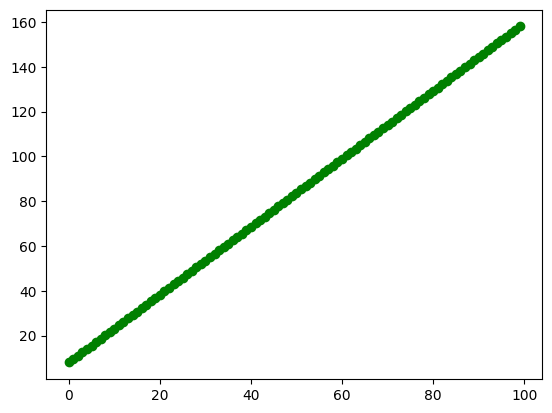

In [23]:
gen_and_plot()

2. Use your optimization from Matrix Derivatives (2) to create a model a linear model that is optimal to fit this and plot it alongside scatter of points, also in green. Report the values of W and b as well.

1.5151515151515154
7.999999999999986


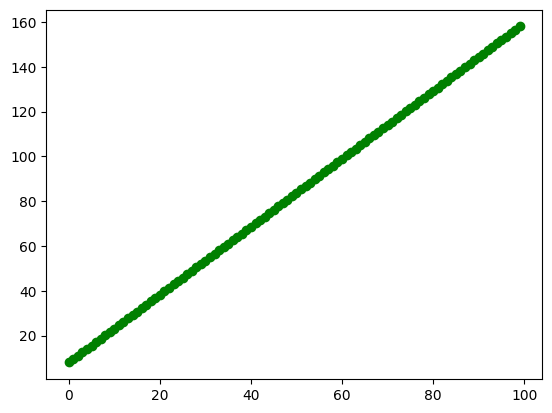

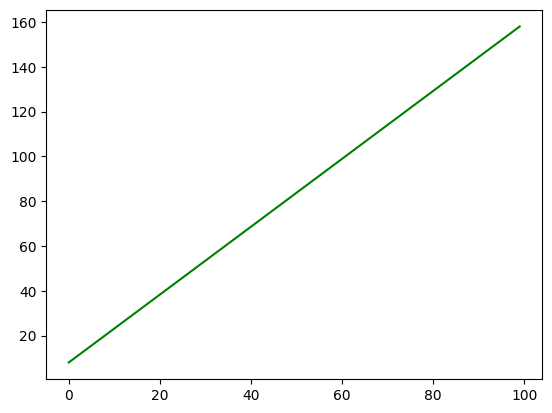

In [29]:
u, x = gen_and_plot()
x_mean = x.mean()
u_mean = u.mean()
x_centered = x - x_mean
u_centered = u - u_mean

W_star = (x_centered @ u_centered) / (x_centered @ x_centered)
b_star = u_mean - x_mean * W_star

print(W_star)
print(b_star)

fig, ax = plt.subplots()

u_pred = W_star * x + b_star
ax.plot(x, u_pred, color = 'green')

3. Create two other datasets from the same distribution but with added Gaussian noise (sampled from a normal distribution) with mean 0 and standard deviation 5 and 10 respectively. Plot these along with their lines of best fit in blue and red respectively (each dataset/line pair are a different color). Make sure that there is a legend with one entry per dataset.

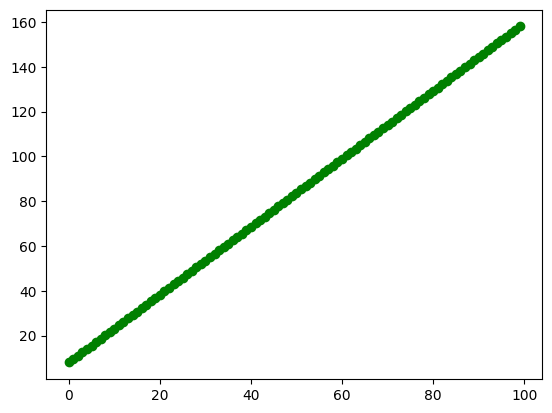

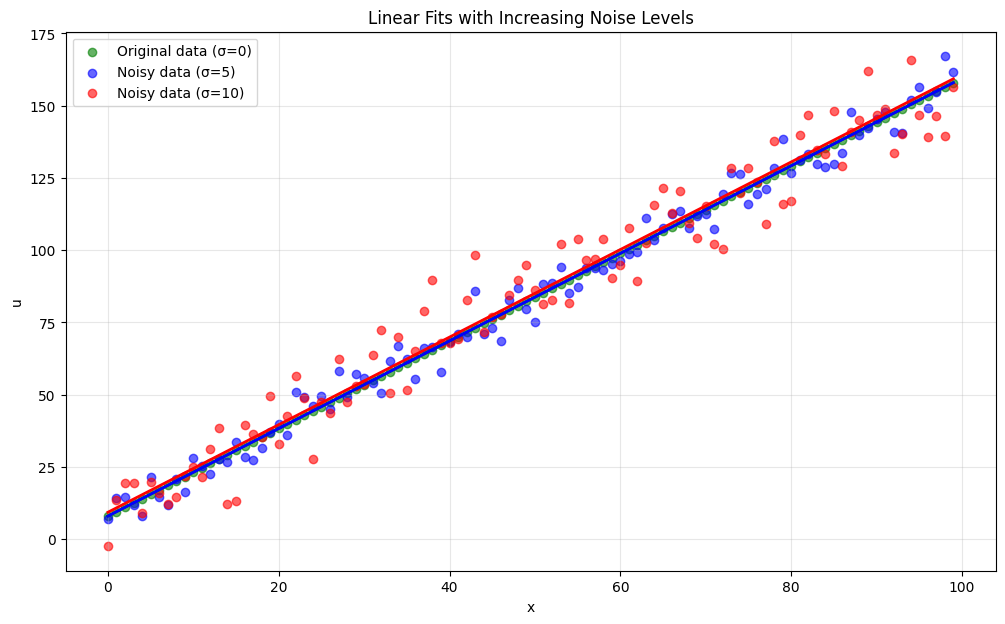

In [32]:
u, x = gen_and_plot()
x_mean = x.mean()
u_mean = u.mean()
x_centered = x - x_mean
u_centered = u - u_mean

W0 = (x_centered @ u_centered) / (x_centered @ x_centered)
b0 = u_mean - x_mean * W_star

u_noise5  = u + np.random.normal(0, 5,  size=len(u))
u_noise10 = u + np.random.normal(0, 10, size=len(u))

u_mean5 = u_noise5.mean()
x_mean5 = x.mean()
x_centered5 = x - x_mean5
u_centered5 = u - u_mean5

W1 = (x_centered5 @ u_centered5) / (x_centered5 @ x_centered5)
b1 = u_mean5 - x_mean5 * W1

u_mean10 = u_noise10.mean()
u_centered10 = u - u_mean10

W2 = (x_centered5 @ u_centered10) / (x_centered5 @ x_centered5)
b2 = u_mean10 - x_mean5 * W2

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(x, u, color='green', alpha=0.6, label='Original data (σ=0)')
ax.plot(x, W0 * x + b0, color='green', linewidth=2)
ax.scatter(x, u_noise5, color='blue', alpha=0.6, label='Noisy data (σ=5)')
ax.plot(x, W1 * x + b1, color='blue', linewidth=2)
ax.scatter(x, u_noise10, color='red', alpha=0.6, label='Noisy data (σ=10)')
ax.plot(x, W2 * x + b2, color='red', linewidth=2)

ax.set_xlabel('x')
ax.set_ylabel('u')
ax.set_title('Linear Fits with Increasing Noise Levels')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

4. (*) Sample data uniformly (non-randomly, i.e. grid-search) from Y ~ 3x1 + 5x2 + 3x1x2 - x2^2 for x1, x2 $\in [0,99]$ (integer values, 10,000 points). Plot both the 3d data as well as a 2d plot of its gradient's magnitude.